# 🏠 House Price Data Analysis
### Simple & Real-World Data Analysis using NumPy, Pandas, Matplotlib & Seaborn

**Dataset:** House Prices (Ames Housing – adapted)  
**Goal:** Understand what factors affect house prices using simple analysis  
**Libraries:** numpy · pandas · matplotlib · seaborn


## Step 1 — Install & Import Libraries

In [13]:
# Run this cell only once to install libraries
# !pip install numpy pandas matplotlib seaborn

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make all plots look clean
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2 — Load the Dataset
> Make sure `house_prices.csv` is in the **same folder** as this notebook.


In [15]:
# Load dataset
df = pd.read_csv('house_prices.csv')

print(f"Total houses  : {df.shape[0]}")
print(f"Total columns : {df.shape[1]}")
print()
# Show first 5 rows
df.head()

Total houses  : 60
Total columns : 58



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,PoolArea,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,61,0,0.0,0.0,2.0,2008.0,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,298,0,0,0.0,0.0,5.0,2007.0,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,42,0,0.0,0.0,9.0,2008.0,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,0,35,272,0.0,0.0,2.0,2006.0,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,192,84,0,0.0,0.0,12.0,2008.0,WD,Normal,250000.0


## Step 3 — Basic Info & Data Types

In [16]:
# Check column names, non-null counts, data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 58 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             60 non-null     int64  
 1   MSSubClass     60 non-null     int64  
 2   MSZoning       60 non-null     str    
 3   LotFrontage    44 non-null     float64
 4   LotArea        60 non-null     int64  
 5   Street         60 non-null     str    
 6   LotShape       60 non-null     str    
 7   LandContour    60 non-null     str    
 8   Utilities      60 non-null     str    
 9   LotConfig      60 non-null     str    
 10  LandSlope      60 non-null     str    
 11  Neighborhood   60 non-null     str    
 12  BldgType       60 non-null     str    
 13  HouseStyle     60 non-null     str    
 14  OverallQual    60 non-null     int64  
 15  OverallCond    60 non-null     int64  
 16  YearBuilt      60 non-null     int64  
 17  YearRemodAdd   60 non-null     int64  
 18  RoofStyle      60 non-n

In [17]:
# Basic statistics for important numeric columns
cols = ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'YearBuilt', 'GarageCars']
df[cols].describe().round(0)

,SalePrice,LotArea,OverallQual,YearBuilt,GarageCars
count,45.0,60.0,60.0,60.0,60.0
mean,192539.0,10356.0,6.0,1973.0,3.0
std,76879.0,2285.0,1.0,25.0,3.0
min,71000.0,6120.0,4.0,1910.0,1.0
25%,139000.0,8438.0,5.0,1958.0,2.0
50%,157000.0,10311.0,6.0,1970.0,2.0
75%,235000.0,11783.0,7.0,2000.0,3.0
max,420000.0,14670.0,9.0,2007.0,11.0


## Step 4 — Missing Values Check

In [18]:
# Count missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing)

Columns with missing values:
LotFrontage      16
ScreenPorch      15
SaleCondition    15
PoolArea         15
MoSold           15
YrSold           15
SalePrice        15
SaleType         15
BsmtQual          2
BsmtCond          2
dtype: int64


In [19]:
# Fill missing values with median (simple and safe approach)
df['LotFrontage']  = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['GarageYrBlt']  = df['GarageYrBlt'].fillna(df['GarageYrBlt'].median())

print("✅ Missing values filled with median.")
print(f"Remaining missing values: {df.isnull().sum().sum()}")

✅ Missing values filled with median.
Remaining missing values: 109


## Step 5 — House Price Distribution
> **Real-world use:** Understand the price range — are houses mostly cheap or expensive?


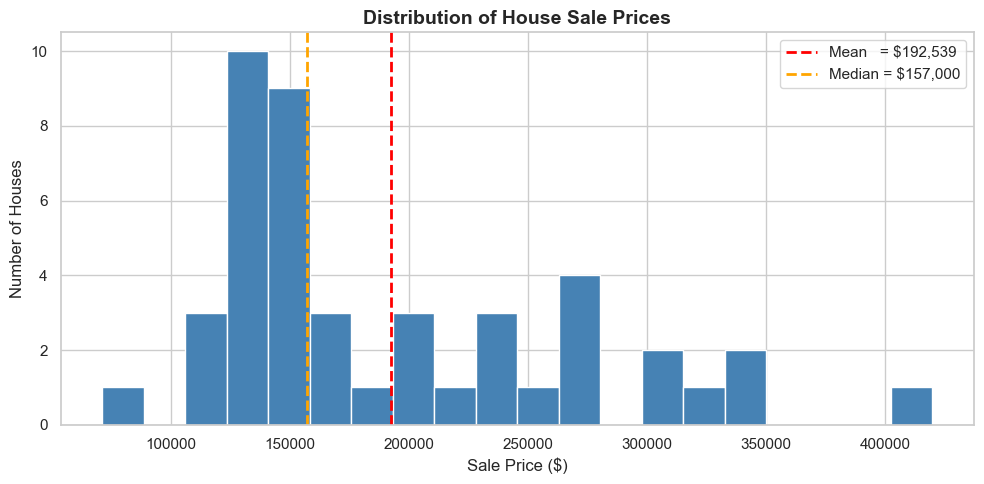

Lowest  Price : $71,000
Highest Price : $420,000
Average Price : $192,539


In [20]:
plt.figure(figsize=(10, 5))
plt.hist(df['SalePrice'], bins=20, color='steelblue', edgecolor='white')

# Add mean and median lines
plt.axvline(df['SalePrice'].mean(),   color='red',    linestyle='--', linewidth=2,
            label=f"Mean   = ${df['SalePrice'].mean():,.0f}")
plt.axvline(df['SalePrice'].median(), color='orange', linestyle='--', linewidth=2,
            label=f"Median = ${df['SalePrice'].median():,.0f}")

plt.title('Distribution of House Sale Prices', fontsize=14, fontweight='bold')
plt.xlabel('Sale Price ($)')
plt.ylabel('Number of Houses')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Lowest  Price : ${df['SalePrice'].min():,.0f}")
print(f"Highest Price : ${df['SalePrice'].max():,.0f}")
print(f"Average Price : ${df['SalePrice'].mean():,.0f}")

## Step 6 — Overall Quality vs Sale Price
> **Real-world use:** Does better build quality mean higher price?


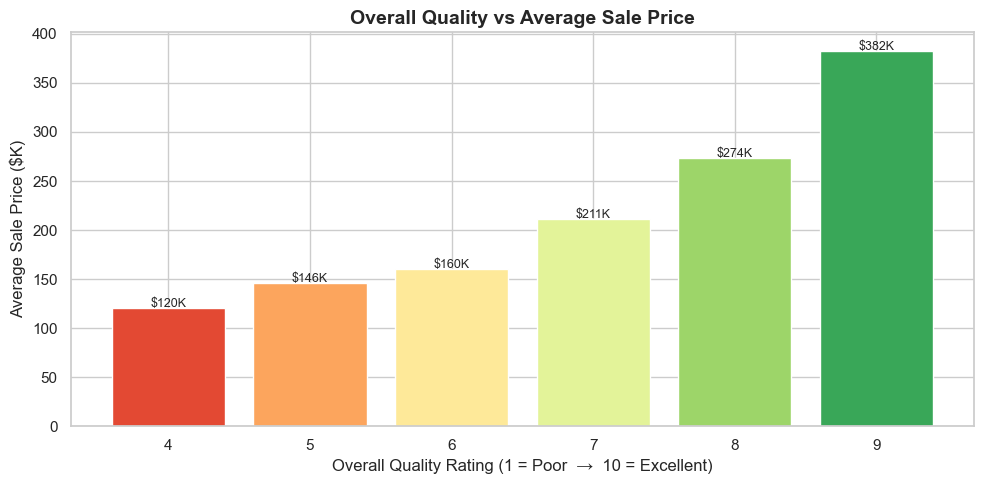

✅ Insight: Higher quality rating = much higher price.


In [21]:
# Average price for each quality rating (1 to 10)
quality_price = df.groupby('OverallQual')['SalePrice'].mean().reset_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(quality_price['OverallQual'], quality_price['SalePrice'] / 1000,
               color=sns.color_palette('RdYlGn', len(quality_price)), edgecolor='white')

# Add price labels on top of bars
for bar, val in zip(bars, quality_price['SalePrice'] / 1000):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'${val:.0f}K', ha='center', fontsize=9)

plt.title('Overall Quality vs Average Sale Price', fontsize=14, fontweight='bold')
plt.xlabel('Overall Quality Rating (1 = Poor  →  10 = Excellent)')
plt.ylabel('Average Sale Price ($K)')
plt.xticks(quality_price['OverallQual'])
plt.tight_layout()
plt.show()

print("✅ Insight: Higher quality rating = much higher price.")

## Step 7 — Living Area vs Sale Price
> **Real-world use:** Bigger house = more expensive? Let's check.


TypeError: can only concatenate str (not "float") to str

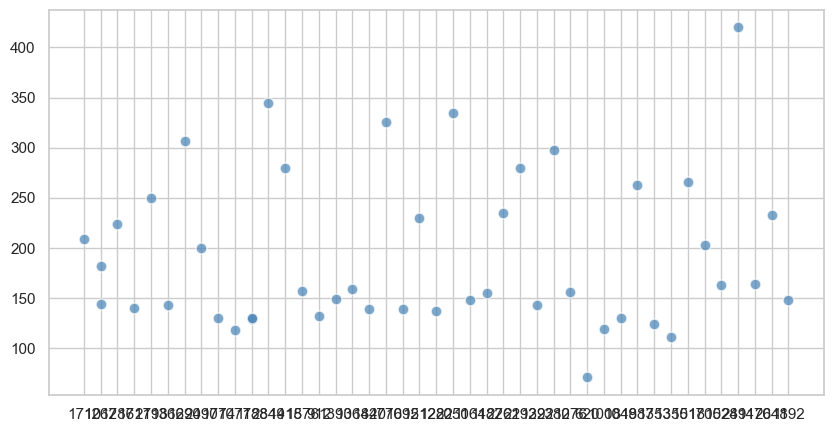

In [22]:
# Drop rows where GrLivArea or SalePrice is missing (fixes np.polyfit TypeError)
plot_df = df[['GrLivArea', 'SalePrice']].dropna()

plt.figure(figsize=(10, 5))
plt.scatter(plot_df['GrLivArea'], plot_df['SalePrice'] / 1000,
            color='steelblue', alpha=0.7, edgecolors='white', s=60)

# Add a trend line
m, b = np.polyfit(plot_df['GrLivArea'], plot_df['SalePrice'] / 1000, 1)
x_vals = np.linspace(plot_df['GrLivArea'].min(), plot_df['GrLivArea'].max(), 100)
plt.plot(x_vals, m * x_vals + b, color='red', linewidth=2,
         label=f'Trend Line (slope = {m:.2f})')

plt.title('Living Area vs Sale Price', fontsize=14, fontweight='bold')
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price ($K)')
plt.legend()
plt.tight_layout()
plt.show()

corr = plot_df['GrLivArea'].corr(plot_df['SalePrice'])
print(f"Correlation between Living Area and Price: {corr:.2f}")
print("✅ Insight: Larger living area → higher price.")

## Step 8 — Neighborhood Price Comparison
> **Real-world use:** Location matters! Which neighborhoods are expensive?


In [ ]:
nbr = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=True) / 1000

plt.figure(figsize=(10, 6))
colors = sns.color_palette('coolwarm', len(nbr))
plt.barh(nbr.index, nbr.values, color=colors, edgecolor='white')

plt.title('Average Sale Price by Neighborhood', fontsize=14, fontweight='bold')
plt.xlabel('Average Sale Price ($K)')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()

print(f"Most  expensive neighborhood : {nbr.idxmax()} (${nbr.max():.0f}K)")
print(f"Least expensive neighborhood : {nbr.idxmin()} (${nbr.min():.0f}K)")

## Step 9 — Year Built vs Sale Price
> **Real-world use:** Are newer houses more expensive than older ones?


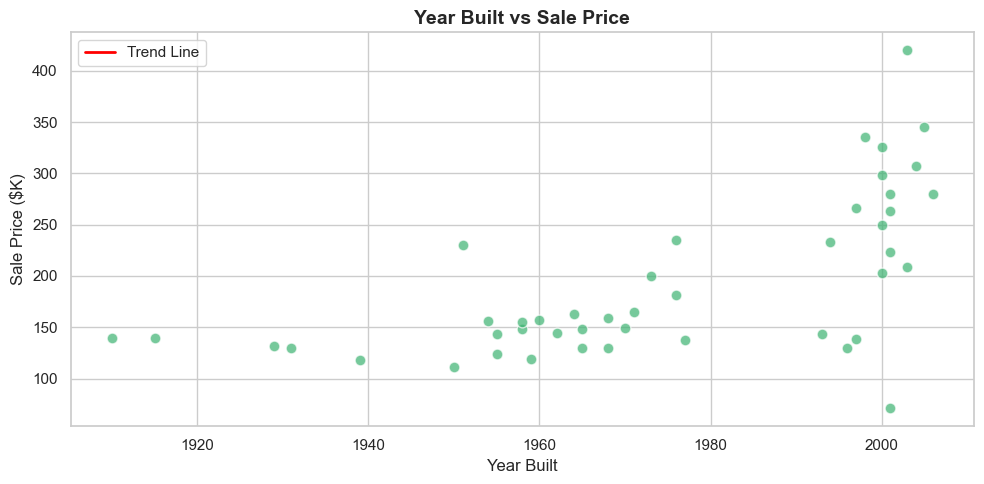

Avg price of houses built before 1970  : $143,848
Avg price of houses built after  2000  : $267,215
✅ Insight: Newer houses are generally more expensive.


In [23]:
plt.figure(figsize=(10, 5))
plt.scatter(df['YearBuilt'], df['SalePrice'] / 1000,
            color='mediumseagreen', alpha=0.7, edgecolors='white', s=60)

# Trend line
m, b = np.polyfit(df['YearBuilt'], df['SalePrice'] / 1000, 1)
x_vals = np.linspace(df['YearBuilt'].min(), df['YearBuilt'].max(), 100)
plt.plot(x_vals, m * x_vals + b, color='red', linewidth=2, label='Trend Line')

plt.title('Year Built vs Sale Price', fontsize=14, fontweight='bold')
plt.xlabel('Year Built')
plt.ylabel('Sale Price ($K)')
plt.legend()
plt.tight_layout()
plt.show()

old   = df[df['YearBuilt'] < 1970]['SalePrice'].mean()
new   = df[df['YearBuilt'] >= 2000]['SalePrice'].mean()
print(f"Avg price of houses built before 1970  : ${old:,.0f}")
print(f"Avg price of houses built after  2000  : ${new:,.0f}")
print("✅ Insight: Newer houses are generally more expensive.")

## Step 10 — Garage Size vs Sale Price
> **Real-world use:** Does having a bigger garage increase house value?


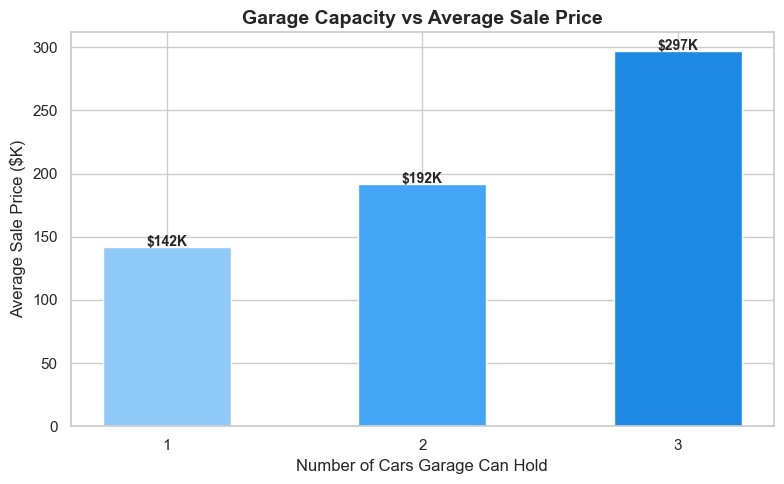

✅ Insight: More garage space → higher house price.


In [24]:
garage_price = df.groupby('GarageCars')['SalePrice'].mean() / 1000

plt.figure(figsize=(8, 5))
bars = plt.bar(garage_price.index.astype(str), garage_price.values,
               color=['#90CAF9', '#42A5F5', '#1E88E5', '#1565C0'][:len(garage_price)],
               edgecolor='white', width=0.5)

for bar, val in zip(bars, garage_price.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'${val:.0f}K', ha='center', fontsize=10, fontweight='bold')

plt.title('Garage Capacity vs Average Sale Price', fontsize=14, fontweight='bold')
plt.xlabel('Number of Cars Garage Can Hold')
plt.ylabel('Average Sale Price ($K)')
plt.tight_layout()
plt.show()

print("✅ Insight: More garage space → higher house price.")

## Step 11 — Correlation Heatmap
> **Real-world use:** Which features are most strongly linked to sale price?


In [ ]:
# Pick the most useful numeric columns
key_cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars',
            'TotalBsmtSF', 'YearBuilt', 'FullBath', 'LotArea']

corr = df[key_cols].corr().round(2)

plt.figure(figsize=(10, 7))
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            linewidths=0.5,
            square=True,
            annot_kws={'size': 11})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top features correlated with SalePrice:")
top = corr['SalePrice'].drop('SalePrice').sort_values(ascending=False)
for feat, val in top.items():
    bar = '█' * int(abs(val) * 20)
    print(f"  {feat:<18} {val:+.2f}  {bar}")

## Step 12 — Monthly Sales Trend
> **Real-world use:** Which month has the most house sales?


In [ ]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly = df.groupby('MoSold')['SalePrice'].agg(['count', 'mean']).reset_index()
monthly['month_name'] = monthly['MoSold'].apply(lambda x: month_names[x - 1])
monthly['mean_k'] = monthly['mean'] / 1000

fig, ax1 = plt.subplots(figsize=(11, 5))

# Bar = number of sales
ax1.bar(monthly['month_name'], monthly['count'],
        color='lightsteelblue', edgecolor='white', label='Number of Sales')
ax1.set_ylabel('Number of Sales', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line = average price
ax2 = ax1.twinx()
ax2.plot(monthly['month_name'], monthly['mean_k'],
         color='tomato', marker='o', linewidth=2.5, label='Avg Price ($K)')
ax2.set_ylabel('Avg Sale Price ($K)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

plt.title('Monthly Sales Volume & Average Price', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.show()

best_month  = monthly.loc[monthly['count'].idxmax(), 'month_name']
cheap_month = monthly.loc[monthly['mean_k'].idxmin(), 'month_name']
print(f"Best month to SELL (most buyers) : {best_month}")
print(f"Best month to BUY  (lowest price): {cheap_month}")

## Step 13 — Price Category Breakdown
> **Real-world use:** How are houses split across budget ranges?


In [ ]:
# Create price buckets
bins   = [0, 130000, 180000, 250000, float('inf')]
labels = ['Budget (<$130K)', 'Mid-Range ($130K–$180K)',
          'Premium ($180K–$250K)', 'Luxury (>$250K)']
df['PriceCategory'] = pd.cut(df['SalePrice'], bins=bins, labels=labels)

counts = df['PriceCategory'].value_counts()
colors = ['#66BB6A', '#42A5F5', '#FFA726', '#EF5350']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 10})
axes[0].set_title('Price Category Share', fontweight='bold')

# Bar chart of avg quality per category
avg_qual = df.groupby('PriceCategory', observed=True)['OverallQual'].mean()
axes[1].bar(avg_qual.index, avg_qual.values, color=colors, edgecolor='white')
axes[1].set_title('Avg Quality Rating per Price Category', fontweight='bold')
axes[1].set_ylabel('Avg Overall Quality')
axes[1].set_ylim(0, 10)
axes[1].tick_params(axis='x', rotation=20)
for i, val in enumerate(avg_qual.values):
    axes[1].text(i, val + 0.1, f'{val:.1f}', ha='center', fontweight='bold')

plt.suptitle('House Price Category Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 14 — Final Summary & Key Insights
> A quick review of everything we learned from this analysis.


In [ ]:
print("=" * 55)
print("   🏠 HOUSE PRICE ANALYSIS — KEY FINDINGS")
print("=" * 55)

avg   = df['SalePrice'].mean()
med   = df['SalePrice'].median()
lo    = df['SalePrice'].min()
hi    = df['SalePrice'].max()

print(f"\n📌 Dataset        : {len(df)} houses")
print(f"📌 Price Range    : ${lo:,.0f}  →  ${hi:,.0f}")
print(f"📌 Average Price  : ${avg:,.0f}")
print(f"📌 Median Price   : ${med:,.0f}")

key_cols = ['SalePrice','OverallQual','GrLivArea','GarageCars',
            'TotalBsmtSF','YearBuilt','FullBath','LotArea']
top_corr = df[key_cols].corr()['SalePrice'].drop('SalePrice')              .abs().sort_values(ascending=False)

print("\n🔑 What affects price the most (correlation):")
for feat, val in top_corr.items():
    stars = '⭐' * round(val * 5)
    print(f"   {feat:<18} {val:.2f}  {stars}")

old_avg = df[df['YearBuilt'] <  1970]['SalePrice'].mean()
new_avg = df[df['YearBuilt'] >= 2000]['SalePrice'].mean()
print(f"\n🏗️  Older homes (<1970) avg price : ${old_avg:,.0f}")
print(f"🏗️  Newer homes (≥2000) avg price : ${new_avg:,.0f}")
print(f"   ➜  Newer homes cost {((new_avg-old_avg)/old_avg*100):.0f}% more on average")

best_nbr = df.groupby('Neighborhood')['SalePrice'].mean().idxmax()
print(f"\n🏆 Most expensive neighborhood   : {best_nbr}")

print("\n✅ Analysis Complete! Use these insights to estimate house prices.")
print("=" * 55)